# EDA

## Imports

In [19]:
from collections import Counter, defaultdict
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_config
from src.utils.data import (
    get_train_images_dir,
    get_test_images_dir,
    get_annotations_path,
    load_annotations,
)

PROJECT_ROOT = get_project_root()
CONFIG = load_config()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation


## Load data

In [2]:
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_data_dir"]

TRAIN_IMAGES_DIR = get_train_images_dir(RAW_DATA_DIR)
TEST_IMAGES_DIR = get_test_images_dir(RAW_DATA_DIR)
ANNOTATIONS_PATH = get_annotations_path(RAW_DATA_DIR)

annotations = load_annotations(ANNOTATIONS_PATH)

## Understanding annotations

In [3]:
print("=" * 60)
print("ANNOTATIONS OVERVIEW")
print("=" * 60)

print(f"\nType: {type(annotations).__name__}")

if isinstance(annotations, dict):
    print("\nTop-level keys:")
    
    for key, value in annotations.items():
        if hasattr(value, "__len__"):
            print(f"  • {key:<20} {type(value).__name__:<10} ({len(value):,} elements)")
        else:
            print(f"  • {key:<20} {type(value).__name__}")

print("\n" + "=" * 60)

ANNOTATIONS OVERVIEW

Type: dict

Top-level keys:
  • info                 dict       (9 elements)
  • licenses             dict       (3 elements)
  • categories           list       (4 elements)
  • images               list       (1,154 elements)
  • annotations          list       (8,199 elements)



### Dataset annotations overview

The annotation file follows a COCO-like structure and contains:

- **1,154 images** with associated metadata.
- **8,199 annotations**, representing the labeled objects/regions in the images.
- **4 categories** defining the types of annotations.
- Additional **dataset metadata** (`info`) and **license information** (`licenses`).

This structure will allow us to analyze the image distribution, annotation categories, and the spatial characteristics of the labeled solar filaments.

In [4]:
print("CATEGORIES")
print("=" * 60)

for category in annotations["categories"]:
    print(category)

CATEGORIES
{'supercategory': 'filament', 'id': 1, 'name': 'Left'}
{'supercategory': 'filament', 'id': 2, 'name': 'Right'}
{'supercategory': 'filament', 'id': 3, 'name': 'Unidentifiable'}
{'supercategory': 'filament', 'id': 4, 'name': 'Ambiguous'}


### Annotation categories

The dataset contains four filament categories, all belonging to the `filament` supercategory:

| ID | Category |
|---:|---|
| 1 | Left |
| 2 | Right |
| 3 | Unidentifiable |
| 4 | Ambiguous |

The labels distinguish filaments according to their identifiable orientation or annotation certainty. We will later analyze their frequency and spatial distribution to determine whether the classes are balanced.

In [5]:
print("ANNOTATION EXAMPLE")
print("=" * 60)

for key, value in annotations["annotations"][0].items():
    print(f"{key:<20}: {value}")

ANNOTATION EXAMPLE
segmentation        : [[480.9382, 850.955, 480.307, 852.0535, 478.2989, 852.451, 476.1202, 851.3087, 471.8813, 845.6188, 469.2107, 844.1978, 460.0, 845.0, 459.0, 844.0, 455.9884, 843.2471, 452.2964, 839.9584, 450.6544, 839.7575, 449.7991, 838.6671, 450.223, 837.6258, 447.5581, 834.6278, 445.4449, 829.1312, 442.9577, 825.6077, 441.8277, 824.4777, 438.6437, 823.5973, 439.0, 821.0, 436.0, 818.0, 435.1557, 815.4672, 433.9753, 817.121, 431.9582, 816.9118, 431.3678, 815.4732, 432.1225, 813.1225, 428.0, 809.0, 426.5642, 809.0, 425.6041, 807.9655, 424.4241, 807.9655, 423.838, 809.0, 421.2093, 807.6935, 417.3793, 808.1037, 414.8921, 809.5546, 410.7452, 813.7726, 408.1003, 813.7726, 407.6903, 812.9902, 404.3743, 813.2522, 402.6286, 813.6471, 402.5948, 814.5982, 401.5748, 815.1882, 400.2097, 813.874, 396.7519, 813.874, 394.3241, 812.5859, 392.7667, 812.7693, 391.5343, 810.7185, 390.8368, 811.7872, 389.6568, 811.7872, 388.4121, 805.8569, 389.0021, 804.8369, 392.6372, 804.8369, 3

### Annotation structure

Each annotation describes a single solar filament and contains both region- and structure-level information:

- **Segmentation:** polygon coordinates defining the filament region.
- **Area:** segmented region area in pixels.
- **Bounding box:** `[x, y, width, height]` enclosing the filament.
- **Spine:** ordered points describing the filament's central axis.
- **Category:** one of four filament classes (`Left`, `Right`, `Unidentifiable`, or `Ambiguous`).
- **Image ID:** links the annotation to its corresponding image.
- **Annotation ID:** unique identifier for each annotation.

The presence of both **segmentation polygons and filament spines** provides information about the shape and geometry of each filament, which can be exploited during exploratory analysis and potentially for more advanced modeling.

In [13]:
print("INFO")
print("=" * 60)

for key, value in annotations["info"].items():
    print(f"{key}: {value}")

INFO
description: MLEcoFi 2024 Dataset - V1.0
url: https://www.mlecofi.net/
version: 1.0
year: 2024
contributor: MLEcoFi Team
date_created: 2024-07-15
team: Earth-Space AI Research Lab (www.esairlab.com)
collaborators: ['National Solar Observatory, Georgia State University']
date_updated: 2026-06-01


In [14]:
print("LICENSES")
print("=" * 60)

for license_info in annotations["licenses"]:
    print(license_info)

LICENSES
url
id
name


In [15]:
print("IMAGE EXAMPLE")
print("=" * 60)

print(annotations["images"][0])

IMAGE EXAMPLE
{'license': 1, 'file_name': '20140609195854Bh.jpeg', 'url': 'https://gong2.nso.edu/HA/hag/201406/20140609/20140609195854Bh.jpg', 'height': 2048, 'width': 2048, 'date_captured': '2014-06-09 19:58:54', 'id': '040301-20140609195854Bh'}


## First images overview

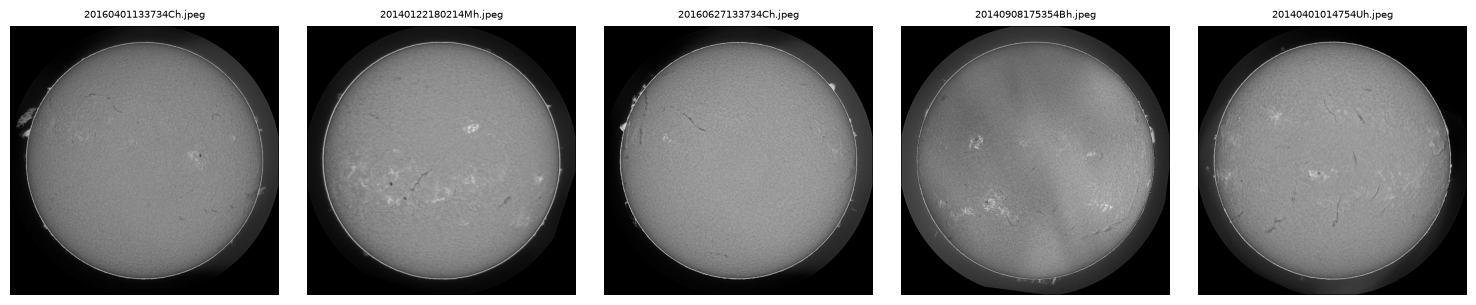

In [8]:
# Obtener imágenes de train
image_paths = list(TRAIN_IMAGES_DIR.iterdir())

# Seleccionar 5 imágenes aleatorias
sample_paths = random.sample(image_paths, 5)

# Visualización
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, image_path in zip(axes, sample_paths):
    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(image_path.name, fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
train_images = list(TRAIN_IMAGES_DIR.iterdir())

extensions = Counter(
    image.suffix.lower()
    for image in train_images
    if image.is_file()
)

sizes = Counter()

for image_path in train_images:
    with Image.open(image_path) as image:
        sizes[image.size] += 1

print("=" * 60)
print("TRAIN IMAGES OVERVIEW")
print("=" * 60)

print(f"\nNumber of images: {len(train_images):,}")

print("\nFile extensions:")
for extension, count in extensions.items():
    print(f"  • {extension}: {count:,}")

print("\nImage sizes:")
for size, count in sizes.most_common():
    print(f"  • {size[0]} × {size[1]}: {count:,}")

print("\n" + "=" * 60)

TRAIN IMAGES OVERVIEW

Number of images: 707

File extensions:
  • .jpeg: 707

Image sizes:
  • 2048 × 2048: 707



In [12]:
modes = Counter()

for image_path in train_images:
    with Image.open(image_path) as image:
        modes[image.mode] += 1

print("=" * 60)
print("IMAGE MODES")
print("=" * 60)

for mode, count in modes.items():
    print(f"  • {mode}: {count:,}")

print("=" * 60)

IMAGE MODES
  • L: 707


### Train image format

The training set contains **707 images**, all stored in `.jpeg` format with a consistent resolution of **2048 × 2048 pixels**.

All images share the same dimensions, so no resizing is required to standardize the dataset at this stage.

We also inspect the image mode to determine the number and type of input channels. This is relevant for defining the preprocessing pipeline and the expected input format of the segmentation model.

All training images are stored in **RGB format**, providing three input channels per image.

In [16]:
# Image filenames declared in the annotation file
json_image_names = {
    image["file_name"]
    for image in annotations["images"]
}

# Image filenames physically present in the train directory
train_image_names = {
    image_path.name
    for image_path in train_images
}

# Compare both sets
common_images = json_image_names & train_image_names
only_in_json = json_image_names - train_image_names
only_in_train = train_image_names - json_image_names

print("=" * 60)
print("IMAGE FILE CONSISTENCY CHECK")
print("=" * 60)

print(f"\nImages declared in JSON:       {len(json_image_names):,}")
print(f"Images in train directory:     {len(train_image_names):,}")
print(f"Images present in both:         {len(common_images):,}")
print(f"Images only in JSON:            {len(only_in_json):,}")
print(f"Images only in train directory: {len(only_in_train):,}")

print("\n" + "=" * 60)

IMAGE FILE CONSISTENCY CHECK

Images declared in JSON:       707
Images in train directory:     707
Images present in both:         707
Images only in JSON:            0
Images only in train directory: 0



In [17]:
image_ids = [image["id"] for image in annotations["images"]]
file_names = [image["file_name"] for image in annotations["images"]]

print("=" * 60)
print("DUPLICATES IN IMAGE METADATA")
print("=" * 60)

print(f"\nTotal image records:       {len(annotations['images']):,}")
print(f"Unique image IDs:          {len(set(image_ids)):,}")
print(f"Unique file names:         {len(set(file_names)):,}")

print(f"\nDuplicated image IDs:      "
      f"{sum(count > 1 for count in Counter(image_ids).values()):,}")

print(f"Duplicated file names:     "
      f"{sum(count > 1 for count in Counter(file_names).values()):,}")

print("=" * 60)

DUPLICATES IN IMAGE METADATA

Total image records:       1,154
Unique image IDs:          1,154
Unique file names:         707

Duplicated image IDs:      0
Duplicated file names:     296


In [18]:
file_counts = Counter(file_names)

# Pick one duplicated filename
duplicated_file = next(
    file_name
    for file_name, count in file_counts.items()
    if count > 1
)

print("=" * 60)
print("DUPLICATED IMAGE EXAMPLE")
print("=" * 60)

print(f"\nFile name: {duplicated_file}")
print(f"Number of records: {file_counts[duplicated_file]}")

print("\nRecords:")
for image in annotations["images"]:
    if image["file_name"] == duplicated_file:
        print(image)

DUPLICATED IMAGE EXAMPLE

File name: 20111116063134Lh.jpeg
Number of records: 3

Records:
{'license': 1, 'file_name': '20111116063134Lh.jpeg', 'url': 'https://gong2.nso.edu/HA/hag/201111/20111116/20111116063134Lh.jpg', 'height': 2048, 'width': 2048, 'date_captured': '2011-11-16 06:31:34', 'id': '050103-20111116063134Lh'}
{'license': 1, 'file_name': '20111116063134Lh.jpeg', 'url': 'https://gong2.nso.edu/HA/hag/201111/20111116/20111116063134Lh.jpg', 'height': 2048, 'width': 2048, 'date_captured': '2011-11-16 06:31:34', 'id': '050102-20111116063134Lh'}
{'license': 1, 'file_name': '20111116063134Lh.jpeg', 'url': 'https://gong2.nso.edu/HA/hag/201111/20111116/20111116063134Lh.jpg', 'height': 2048, 'width': 2048, 'date_captured': '2011-11-16 06:31:34', 'id': '050101-20111116063134Lh'}


In [20]:
# Group image records by file name
images_by_file = defaultdict(list)

for image in annotations["images"]:
    images_by_file[image["file_name"]].append(image)

# Keep only duplicated file names
duplicated_images = {
    file_name: records
    for file_name, records in images_by_file.items()
    if len(records) > 1
}

# Check whether duplicated records differ in any field other than "id"
inconsistent_duplicates = {}

for file_name, records in duplicated_images.items():
    reference = {
        key: value
        for key, value in records[0].items()
        if key != "id"
    }

    for record in records[1:]:
        current = {
            key: value
            for key, value in record.items()
            if key != "id"
        }

        if current != reference:
            inconsistent_duplicates[file_name] = records
            break

print("=" * 60)
print("DUPLICATE IMAGE METADATA CHECK")
print("=" * 60)

print(f"\nDuplicated file names:              {len(duplicated_images):,}")
print(f"Consistent duplicates:              "
      f"{len(duplicated_images) - len(inconsistent_duplicates):,}")
print(f"Inconsistent duplicates:            "
      f"{len(inconsistent_duplicates):,}")

print("=" * 60)

DUPLICATE IMAGE METADATA CHECK

Duplicated file names:              296
Consistent duplicates:              296
Inconsistent duplicates:            0


### Image file consistency

The annotation file contains **1,154 image records**, but only **707 unique image file names**, matching the **707 physical training images** in the dataset.

Some file names appear multiple times in the JSON. These records correspond to different image IDs but contain identical metadata apart from the `id` field.

A consistency check across all **296 duplicated file names** confirmed that their metadata is identical in every case.

Therefore, these duplicates do not represent different image files or conflicting metadata, and they do not affect the analysis. For the following steps, we will use the **unique image file names** to identify the physical images in the training set.